In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.color": "#e5e7eb",
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

OUTPUT_DIR = Path(".")
LAGS = [1, 7, 14, 28, 365]
ROLLS = [7, 28]
CV_CUTOFFS = [pd.Timestamp("2020-01-01"), pd.Timestamp("2021-01-01"), pd.Timestamp("2022-01-01")]
SHAP_SAMPLE_SIZE = 350
SHAP_TOP_N = 15

DATE_FEATURES = [
    "year",
    "month",
    "day",
    "dow",
    "doy",
    "week",
    "quarter",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_quarter_start",
    "is_quarter_end",
    "is_year_start",
    "is_year_end",
    "days_in_month",
    "month_progress",
    "days_to_month_end",
    "days_to_year_end",
    "days_since_tet",
    "days_until_tet",
    "days_to_nearest_tet",
    "is_tet_window_7",
    "is_tet_window_14",
    "is_tet_window_30",
]

TET_DATES = pd.to_datetime(
    [
        "2013-02-10",
        "2014-01-31",
        "2015-02-19",
        "2016-02-08",
        "2017-01-28",
        "2018-02-16",
        "2019-02-05",
        "2020-01-25",
        "2021-02-12",
        "2022-02-01",
        "2023-01-22",
        "2024-02-10",
        "2025-01-29",
    ]
)

XGB_PARAMS = {
    "n_estimators": 700,
    "learning_rate": 0.05,
    "max_depth": 6,
    "min_child_weight": 3,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_lambda": 1.0,
    "random_state": 42,
}
RIDGE_ALPHA = 2.0
ENSEMBLE_WEIGHTS = np.array([0.8, 0.2])


In [2]:
def find_base_dir() -> Path:
    candidates = [
        Path("/kaggle/input/competitions/datathon-2026-round-1"),
        Path("/kaggle/input/datathon-2026-round-1"),
        Path("."),
    ]
    for candidate in candidates:
        if (candidate / "sales.csv").exists() and (candidate / "sample_submission.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find sales.csv and sample_submission.csv in the expected folders.")


def add_date_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Date"] = pd.to_datetime(out["Date"])
    out["year"] = out["Date"].dt.year
    out["month"] = out["Date"].dt.month
    out["day"] = out["Date"].dt.day
    out["dow"] = out["Date"].dt.dayofweek
    out["doy"] = out["Date"].dt.dayofyear
    out["week"] = out["Date"].dt.isocalendar().week.astype(int)
    out["quarter"] = out["Date"].dt.quarter
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    out["dow_sin"] = np.sin(2 * np.pi * out["dow"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dow"] / 7)
    out["doy_sin"] = np.sin(2 * np.pi * out["doy"] / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * out["doy"] / 365.25)
    out["is_weekend"] = out["dow"].isin([5, 6]).astype(int)
    out["is_month_start"] = out["Date"].dt.is_month_start.astype(int)
    out["is_month_end"] = out["Date"].dt.is_month_end.astype(int)
    out["is_quarter_start"] = out["Date"].dt.is_quarter_start.astype(int)
    out["is_quarter_end"] = out["Date"].dt.is_quarter_end.astype(int)
    out["is_year_start"] = out["Date"].dt.is_year_start.astype(int)
    out["is_year_end"] = out["Date"].dt.is_year_end.astype(int)
    out["days_in_month"] = out["Date"].dt.days_in_month
    out["month_progress"] = (out["day"] - 1) / out["days_in_month"]
    out["days_to_month_end"] = out["days_in_month"] - out["day"]

    year_end = out["Date"].dt.to_period("Y").dt.end_time.dt.normalize()
    out["days_to_year_end"] = (year_end - out["Date"]).dt.days

    tet = TET_DATES.values.astype("datetime64[ns]")
    dates = out["Date"].values.astype("datetime64[ns]")
    idx = np.searchsorted(tet, dates, side="left")
    prev_idx = np.clip(idx - 1, 0, len(tet) - 1)
    next_idx = np.clip(idx, 0, len(tet) - 1)
    prev_tet = tet[prev_idx]
    next_tet = tet[next_idx]
    days_since_tet = (dates - prev_tet).astype("timedelta64[D]").astype(float)
    days_until_tet = (next_tet - dates).astype("timedelta64[D]").astype(float)
    days_to_nearest_tet = np.minimum(np.abs(days_since_tet), np.abs(days_until_tet))
    out["days_since_tet"] = days_since_tet
    out["days_until_tet"] = days_until_tet
    out["days_to_nearest_tet"] = days_to_nearest_tet
    out["is_tet_window_7"] = (days_to_nearest_tet <= 7).astype(int)
    out["is_tet_window_14"] = (days_to_nearest_tet <= 14).astype(int)
    out["is_tet_window_30"] = (days_to_nearest_tet <= 30).astype(int)
    return out


def add_target_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for target in ["Revenue", "COGS"]:
        for lag in LAGS:
            out[f"{target.lower()}_lag_{lag}"] = out[target].shift(lag)
        for win in ROLLS:
            out[f"{target.lower()}_roll_{win}"] = out[target].shift(1).rolling(win).mean()
    return out


def build_frame(history: pd.DataFrame) -> pd.DataFrame:
    frame = history[["Date", "Revenue", "COGS"]].copy()
    frame = frame.sort_values("Date").reset_index(drop=True)
    frame = add_date_features(frame)
    frame = add_target_features(frame)
    return frame


def revenue_cols() -> list[str]:
    cols = list(DATE_FEATURES)
    cols += [f"revenue_lag_{lag}" for lag in LAGS]
    cols += [f"revenue_roll_{win}" for win in ROLLS]
    return cols


def cogs_cols() -> list[str]:
    cols = list(DATE_FEATURES) + ["Revenue"]
    cols += [f"revenue_lag_{lag}" for lag in LAGS]
    cols += [f"revenue_roll_{win}" for win in ROLLS]
    cols += [f"cogs_lag_{lag}" for lag in LAGS]
    cols += [f"cogs_roll_{win}" for win in ROLLS]
    return cols


def fit_xgb(train_frame: pd.DataFrame, target: str, feature_cols: list[str]) -> XGBRegressor:
    model = XGBRegressor(
        **XGB_PARAMS,
        tree_method="hist",
        objective="reg:squarederror",
        n_jobs=-1,
    )
    model.fit(train_frame[feature_cols], train_frame[target])
    return model


def fit_ridge(train_frame: pd.DataFrame, target: str, feature_cols: list[str]):
    model = make_pipeline(StandardScaler(), Ridge(alpha=RIDGE_ALPHA))
    model.fit(train_frame[feature_cols], train_frame[target])
    return model


def fit_family(train_frame: pd.DataFrame, target: str, feature_cols: list[str], use_ensemble: bool):
    models = [fit_xgb(train_frame, target, feature_cols)]
    if use_ensemble:
        models.append(fit_ridge(train_frame, target, feature_cols))
    return models


def predict_family(models, row: pd.DataFrame, feature_cols: list[str]) -> float:
    preds = [float(model.predict(row[feature_cols])[0]) for model in models]
    if len(preds) == 1:
        return max(preds[0], 0.0)
    return max(float(np.average(preds, weights=ENSEMBLE_WEIGHTS[: len(preds)])), 0.0)


def recursive_score(train_hist: pd.DataFrame, valid_hist: pd.DataFrame, revenue_models, cogs_models) -> dict[str, float]:
    history = train_hist[["Date", "Revenue", "COGS"]].copy().reset_index(drop=True)
    rev_preds = []
    cogs_preds = []

    rev_features = revenue_cols()
    cogs_features = cogs_cols()

    for d in pd.to_datetime(valid_hist["Date"]):
        future_row = pd.DataFrame({"Date": [d], "Revenue": [np.nan], "COGS": [np.nan]})
        temp = pd.concat([history, future_row], ignore_index=True).sort_values("Date").reset_index(drop=True)

        temp_frame = build_frame(temp)
        rev_row = temp_frame.iloc[[-1]].copy()
        rev_pred = predict_family(revenue_models, rev_row, rev_features)

        temp.loc[temp.index[-1], "Revenue"] = rev_pred
        temp_frame = build_frame(temp)
        cogs_row = temp_frame.iloc[[-1]].copy()
        cogs_pred = predict_family(cogs_models, cogs_row, cogs_features)

        rev_preds.append(rev_pred)
        cogs_preds.append(cogs_pred)
        history = pd.concat(
            [history, pd.DataFrame({"Date": [d], "Revenue": [rev_pred], "COGS": [cogs_pred]})],
            ignore_index=True,
        )

    return {
        "Revenue_MAE": mean_absolute_error(valid_hist["Revenue"], rev_preds),
        "Revenue_RMSE": mean_squared_error(valid_hist["Revenue"], rev_preds) ** 0.5,
        "Revenue_R2": r2_score(valid_hist["Revenue"], rev_preds),
        "COGS_MAE": mean_absolute_error(valid_hist["COGS"], cogs_preds),
        "COGS_RMSE": mean_squared_error(valid_hist["COGS"], cogs_preds) ** 0.5,
        "COGS_R2": r2_score(valid_hist["COGS"], cogs_preds),
        "Total_MAE": mean_absolute_error(valid_hist["Revenue"], rev_preds)
        + mean_absolute_error(valid_hist["COGS"], cogs_preds),
    }


def evaluate_family(frame: pd.DataFrame, sales: pd.DataFrame, use_ensemble: bool) -> pd.DataFrame:
    rows = []
    for cutoff in CV_CUTOFFS:
        valid_end = cutoff + pd.DateOffset(years=1)
        train_hist = sales[sales["Date"] < cutoff].copy().reset_index(drop=True)
        valid_hist = sales[(sales["Date"] >= cutoff) & (sales["Date"] < valid_end)].copy().reset_index(drop=True)
        train_frame = frame[frame["Date"] < cutoff].copy().reset_index(drop=True)
        revenue_models = fit_family(train_frame, "Revenue", revenue_cols(), use_ensemble)
        cogs_models = fit_family(train_frame, "COGS", cogs_cols(), use_ensemble)
        metrics = recursive_score(train_hist, valid_hist, revenue_models, cogs_models)
        metrics["fold"] = cutoff.year
        rows.append(metrics)
    return pd.DataFrame(rows)


def forecast_submission(train_hist: pd.DataFrame, sample: pd.DataFrame, revenue_models, cogs_models) -> pd.DataFrame:
    history = train_hist[["Date", "Revenue", "COGS"]].copy().reset_index(drop=True)
    preds = []
    rev_features = revenue_cols()
    cogs_features = cogs_cols()

    for d in pd.to_datetime(sample["Date"]):
        future_row = pd.DataFrame({"Date": [d], "Revenue": [np.nan], "COGS": [np.nan]})
        temp = pd.concat([history, future_row], ignore_index=True).sort_values("Date").reset_index(drop=True)

        temp_frame = build_frame(temp)
        rev_row = temp_frame.iloc[[-1]].copy()
        rev_pred = predict_family(revenue_models, rev_row, rev_features)

        temp.loc[temp.index[-1], "Revenue"] = rev_pred
        temp_frame = build_frame(temp)
        cogs_row = temp_frame.iloc[[-1]].copy()
        cogs_pred = predict_family(cogs_models, cogs_row, cogs_features)

        preds.append((d, rev_pred, cogs_pred))
        history = pd.concat(
            [history, pd.DataFrame({"Date": [d], "Revenue": [rev_pred], "COGS": [cogs_pred]})],
            ignore_index=True,
        )

    return pd.DataFrame(preds, columns=["Date", "Revenue", "COGS"])


def save_feature_importance(model, feature_cols: list[str], path: Path) -> None:
    importance = pd.DataFrame(
        {
            "feature": feature_cols,
            "importance": model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)
    importance.to_csv(path, index=False)


def save_shap_artifacts(
    model,
    feature_cols: list[str],
    frame: pd.DataFrame,
    csv_path: Path,
    bar_path: Path,
    sample_size: int = SHAP_SAMPLE_SIZE,
) -> None:
    sample = frame.sample(min(sample_size, len(frame)), random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(sample[feature_cols])
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = np.asarray(shap_values)
    shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).sort_values(ascending=False)
    shap_importance.to_csv(csv_path, header=["mean_abs_shap"])

    top = shap_importance.head(min(SHAP_TOP_N, len(shap_importance))).sort_values(ascending=True)
    colors = plt.cm.viridis(np.linspace(0.30, 0.90, len(top)))

    fig, ax = plt.subplots(figsize=(10, max(4.5, 0.38 * len(top) + 1.1)), dpi=220)
    ax.barh(top.index, top.values, color=colors, edgecolor="none")
    ax.set_title(f"{csv_path.stem.replace('_', ' ').title()} | Mean Absolute SHAP", pad=12, fontweight="bold")
    ax.set_xlabel("Mean |SHAP|")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="-", alpha=0.65)
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", length=0)
    for idx, value in enumerate(top.values):
        ax.text(value * 1.01, idx, f"{value:,.0f}", va="center", ha="left", fontsize=8)
    fig.tight_layout()
    fig.savefig(bar_path, dpi=220, bbox_inches="tight", facecolor="white")
    plt.close(fig)


In [3]:
base_dir = find_base_dir()
sales = pd.read_csv(base_dir / "sales.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
sample = pd.read_csv(base_dir / "sample_submission.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

full_frame = build_frame(sales).dropna().copy()
cutoff = pd.Timestamp("2022-01-01")
train_hist = sales[sales["Date"] < cutoff].copy().reset_index(drop=True)
valid_hist = sales[sales["Date"] >= cutoff].copy().reset_index(drop=True)
train_pre = full_frame[full_frame["Date"] < cutoff].copy().reset_index(drop=True)

pd.Series(
    {
        "Sales rows": len(sales),
        "Sample rows": len(sample),
        "Train pre-2022 rows": len(train_pre),
        "Validation rows": len(valid_hist),
        "Revenue features": len(revenue_cols()),
        "COGS features": len(cogs_cols()),
    }
)


Sales rows             3833
Sample rows             548
Train pre-2022 rows    3103
Validation rows         365
Revenue features         37
COGS features            45
dtype: int64

In [4]:
single_cv = evaluate_family(train_pre, sales, use_ensemble=False)
ensemble_cv = evaluate_family(train_pre, sales, use_ensemble=True)

metric_cols = [
    "Revenue_MAE",
    "Revenue_RMSE",
    "Revenue_R2",
    "COGS_MAE",
    "COGS_RMSE",
    "COGS_R2",
    "Total_MAE",
]

single_summary = {"strategy": "single"}
ensemble_summary = {"strategy": "ensemble"}
for col in metric_cols:
    single_summary[col] = float(single_cv[col].mean())
    ensemble_summary[col] = float(ensemble_cv[col].mean())

cv_summary = pd.DataFrame([single_summary, ensemble_summary]).sort_values("Total_MAE").reset_index(drop=True)
selected_strategy = cv_summary.iloc[0]["strategy"]

single_cv.to_csv(OUTPUT_DIR / "cv_single_folds.csv", index=False)
ensemble_cv.to_csv(OUTPUT_DIR / "cv_ensemble_folds.csv", index=False)
cv_summary.to_csv(OUTPUT_DIR / "cv_summary.csv", index=False)

cv_summary


,strategy,Revenue_MAE,Revenue_RMSE,Revenue_R2,COGS_MAE,COGS_RMSE,COGS_R2,Total_MAE
0,single,688875.495126,9.975766e+05,0.628546,588692.012584,827964.435381,0.658562,1.277568e+06
1,ensemble,741470.413068,1.066200e+06,0.576056,617360.252869,869058.297513,0.623812,1.358831e+06


In [5]:
use_ensemble = selected_strategy == "ensemble"

revenue_models = fit_family(full_frame, "Revenue", revenue_cols(), use_ensemble)
cogs_models = fit_family(full_frame, "COGS", cogs_cols(), use_ensemble)

save_feature_importance(revenue_models[0], revenue_cols(), OUTPUT_DIR / "feature_importance_revenue.csv")
save_feature_importance(cogs_models[0], cogs_cols(), OUTPUT_DIR / "feature_importance_cogs.csv")
save_shap_artifacts(
    revenue_models[0],
    revenue_cols(),
    full_frame,
    OUTPUT_DIR / "shap_importance_revenue.csv",
    OUTPUT_DIR / "shap_bar_revenue.png",
)
save_shap_artifacts(
    cogs_models[0],
    cogs_cols(),
    full_frame,
    OUTPUT_DIR / "shap_importance_cogs.csv",
    OUTPUT_DIR / "shap_bar_cogs.png",
)

pd.Series(
    {
        "selected_strategy": selected_strategy,
        "shap_outputs": 2,
    },
    name="value",
)


selected_strategy    single
shap_outputs              2
Name: value, dtype: object

In [6]:
submission = forecast_submission(train_hist=sales, sample=sample, revenue_models=revenue_models, cogs_models=cogs_models)
submission.to_csv(OUTPUT_DIR / "submission.csv", index=False)
submission.head()


,Date,Revenue,COGS
0,2023-01-01,1990473.125,1.866770e+06
1,2023-01-02,1497005.625,1.288136e+06
2,2023-01-03,1141875.250,9.348604e+05
3,2023-01-04,1071468.500,8.870371e+05
4,2023-01-05,1067907.000,8.940473e+05


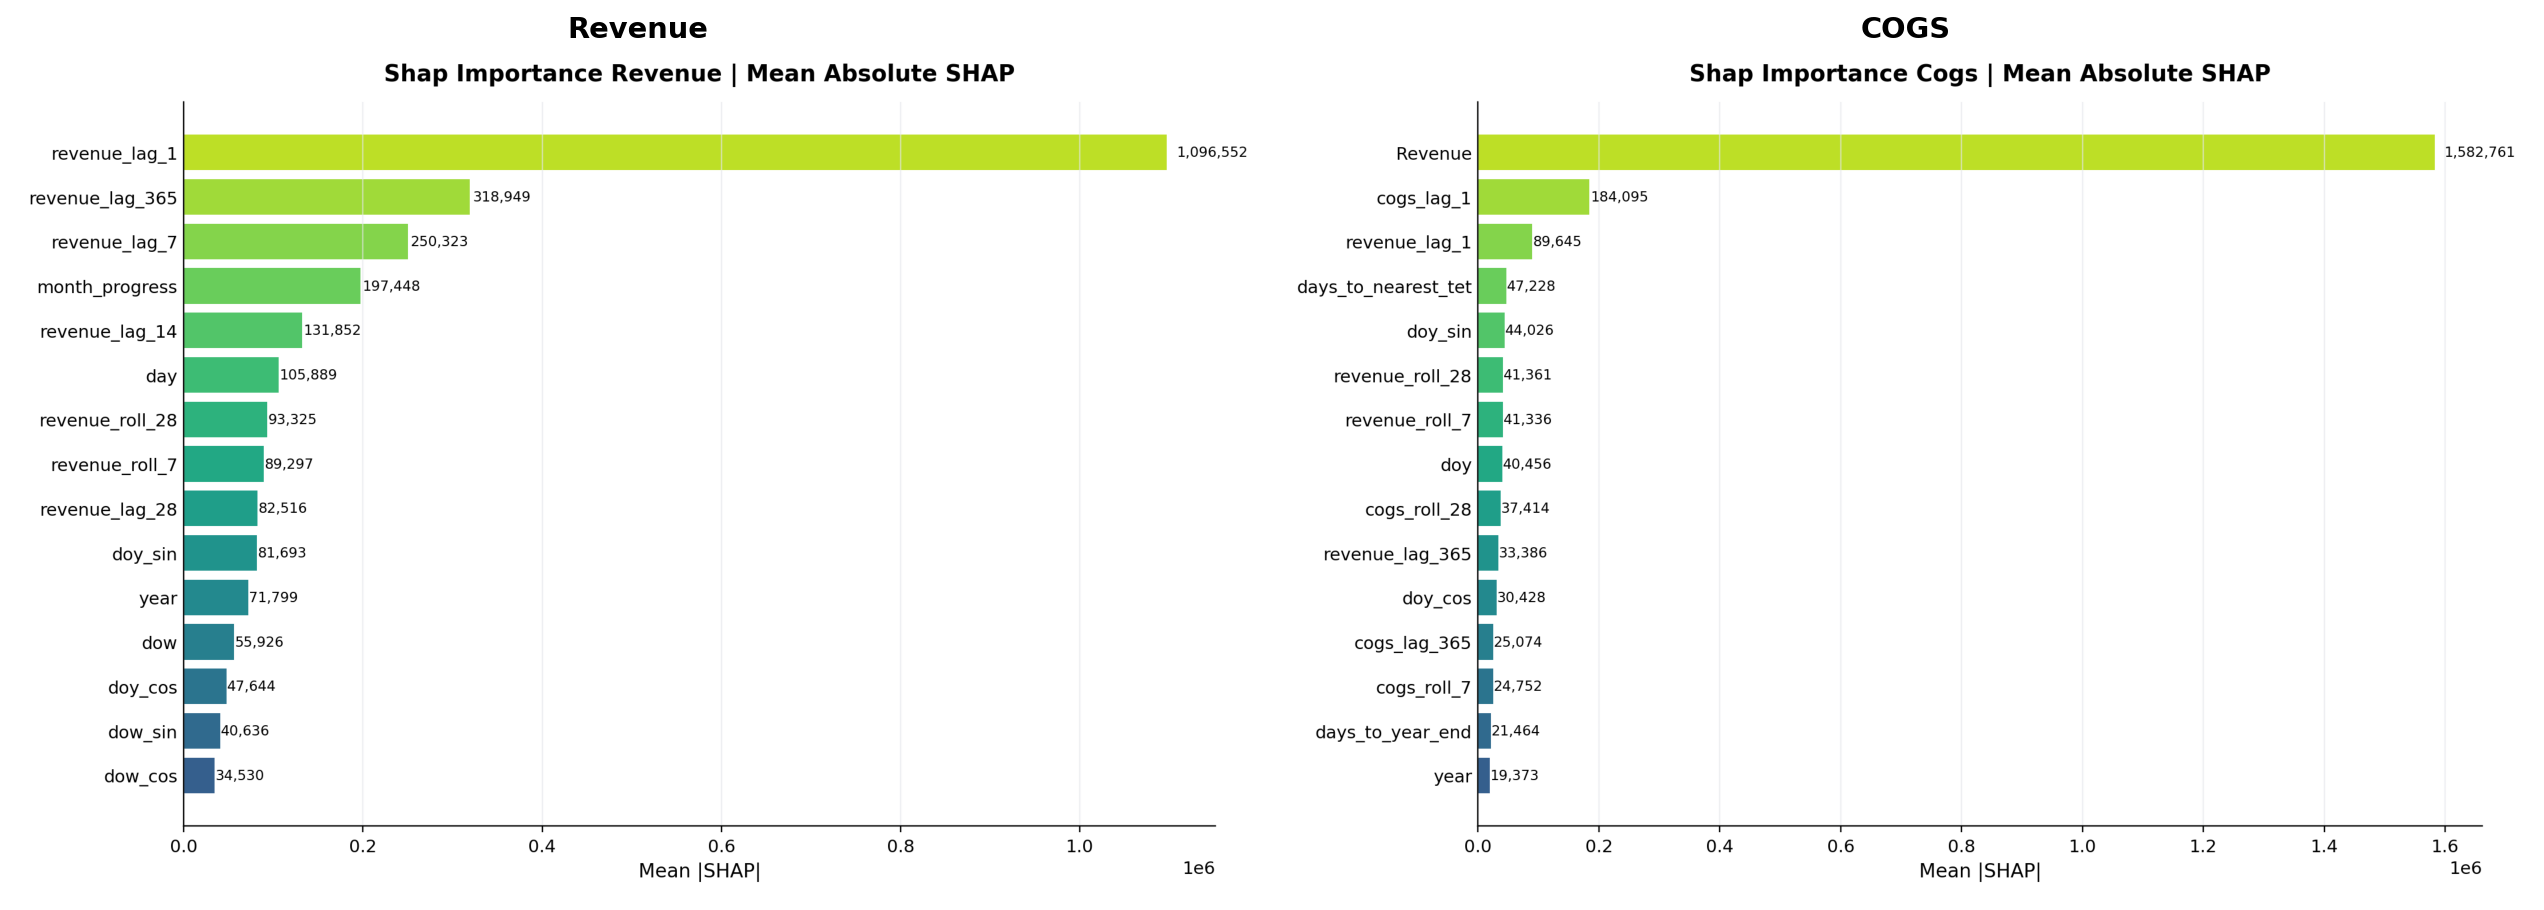

In [7]:
from IPython.display import display
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=160)
for ax, title, path in [
    (axes[0], "Revenue", OUTPUT_DIR / "shap_bar_revenue.png"),
    (axes[1], "COGS", OUTPUT_DIR / "shap_bar_cogs.png"),
]:
    ax.imshow(Image.open(path))
    ax.set_title(title, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.show()
